In [35]:
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.util import ngrams
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import chardet
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [36]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [37]:
with open("positive-words.txt", "rb") as file:
    positive_words = chardet.detect(file.read())["encoding"]

with open("negative-words.txt", "rb") as file:
    negative_words = chardet.detect(file.read())["encoding"]

with open("stop.txt", "rb") as file:
    stop_words = chardet.detect(file.read())["encoding"]

In [38]:
reviews = [
    "You can choose it without any confusions, very good device...",
    "Camera not up to the mark , not enough fast charging support, better glassy finish and great look",
    "Battery backup less than 5 hours",
    "This is an Okayish mobile around 10k.",
    "Brought it for my father & he is happy with it.Good for day to day tasks. YouTube, WhatsApp, Facebook and other regular apps work seamlessly.Average to good rating for the speedGood looks.Would have said value for money if priced below 10k.Software experience is a nightmare as it is full of bloatware. Takes lots and lots of time to remove the bloatware and the advertisements. Lots of setting have to be done.Good part is that it runs on Android 13 out of the box.Videos and photos are ok & watching media is ok too considering its price range",
    "The phone is fab, everything is fantastic in this price range, and yeah, 5G support is the main reason behind buying it. I am very satisfied and happy to go with this purchase.."
]


In [39]:
def calculate_sentiment(review):
    tokens = word_tokenize(review.lower())
    filtered_tokens = [word for word in tokens if word not in stop_words]
    positive_count = sum(1 for word in filtered_tokens if word in positive_words)
    negative_count = sum(1 for word in filtered_tokens if word in negative_words)
    sentiment_score = (positive_count - negative_count) / len(filtered_tokens)
    return sentiment_score

In [40]:
sentiments = []
for i, review in enumerate(reviews, 1):
    sentiment_score = calculate_sentiment(review)
    if sentiment_score > 0:
        sentiment = 'Positive'
    elif sentiment_score < 0:
        sentiment = 'Negative'
    else:
        sentiment = 'Neutral'
    sentiments.append(sentiment)
    print('Review:',review)
    print('Sentiment:',sentiment)
    print()

Review: You can choose it without any confusions, very good device...
Sentiment: Neutral

Review: Camera not up to the mark , not enough fast charging support, better glassy finish and great look
Sentiment: Neutral

Review: Battery backup less than 5 hours
Sentiment: Negative

Review: This is an Okayish mobile around 10k.
Sentiment: Neutral

Review: Brought it for my father & he is happy with it.Good for day to day tasks. YouTube, WhatsApp, Facebook and other regular apps work seamlessly.Average to good rating for the speedGood looks.Would have said value for money if priced below 10k.Software experience is a nightmare as it is full of bloatware. Takes lots and lots of time to remove the bloatware and the advertisements. Lots of setting have to be done.Good part is that it runs on Android 13 out of the box.Videos and photos are ok & watching media is ok too considering its price range
Sentiment: Neutral

Review: The phone is fab, everything is fantastic in this price range, and yeah, 5

<ipython-input-41-79b2f343eeda>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=sentiments, palette='viridis')


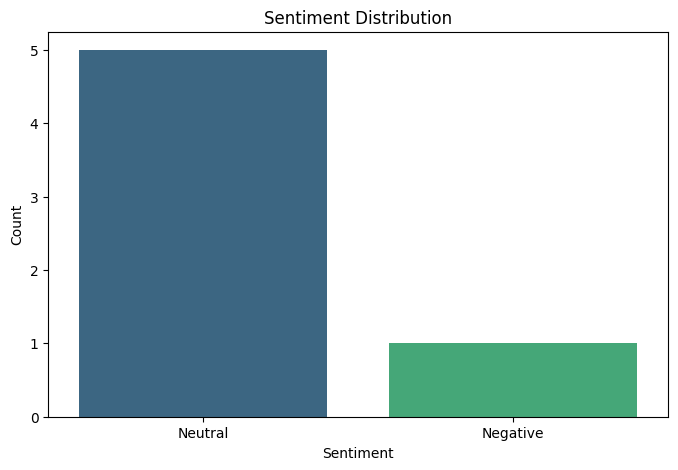

In [41]:
plt.figure(figsize=(8, 5))
sns.countplot(x=sentiments, palette='viridis')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


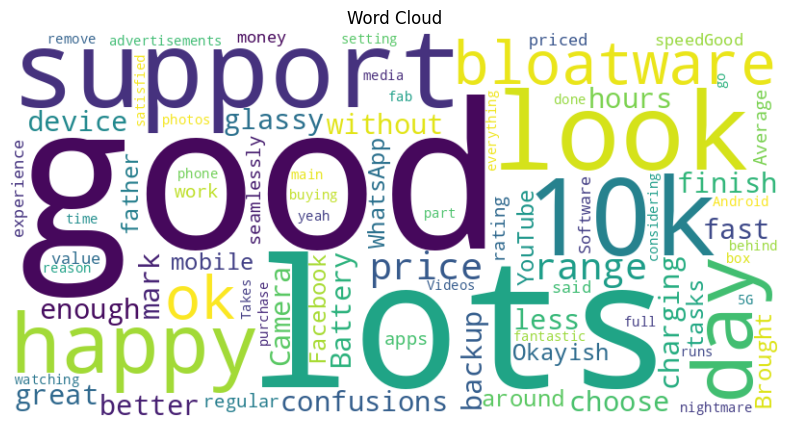

In [42]:
all_reviews = ' '.join(reviews)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_reviews)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud')
plt.show()


In [43]:
for i, review in enumerate(reviews, 1):
    ngrams_3 = [ngram for ngram in ngrams(word_tokenize(review.lower()), 3)]
    print("Review N-grams:",ngrams_3)


Review N-grams: [('you', 'can', 'choose'), ('can', 'choose', 'it'), ('choose', 'it', 'without'), ('it', 'without', 'any'), ('without', 'any', 'confusions'), ('any', 'confusions', ','), ('confusions', ',', 'very'), (',', 'very', 'good'), ('very', 'good', 'device'), ('good', 'device', '...')]
Review N-grams: [('camera', 'not', 'up'), ('not', 'up', 'to'), ('up', 'to', 'the'), ('to', 'the', 'mark'), ('the', 'mark', ','), ('mark', ',', 'not'), (',', 'not', 'enough'), ('not', 'enough', 'fast'), ('enough', 'fast', 'charging'), ('fast', 'charging', 'support'), ('charging', 'support', ','), ('support', ',', 'better'), (',', 'better', 'glassy'), ('better', 'glassy', 'finish'), ('glassy', 'finish', 'and'), ('finish', 'and', 'great'), ('and', 'great', 'look')]
Review N-grams: [('battery', 'backup', 'less'), ('backup', 'less', 'than'), ('less', 'than', '5'), ('than', '5', 'hours')]
Review N-grams: [('this', 'is', 'an'), ('is', 'an', 'okayish'), ('an', 'okayish', 'mobile'), ('okayish', 'mobile', 'ar

In [44]:
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(reviews)
feature_names = vectorizer.get_feature_names_out()
print(tfidf_matrix.toarray())
print(feature_names)

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.33663845 0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.33663845 0.         0.33663845 0.33663845 0.
  0.         0.33663845 0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.27604835 0.
  0.         0.         0.         0.         0.         0.
  0.         0.23305898 0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.   

In [45]:
sum_words = tfidf_matrix.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:10]

<ipython-input-46-c0d3459b1901>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[word[0] for word in words_freq], y=[word[1] for word in words_freq], palette='mako')


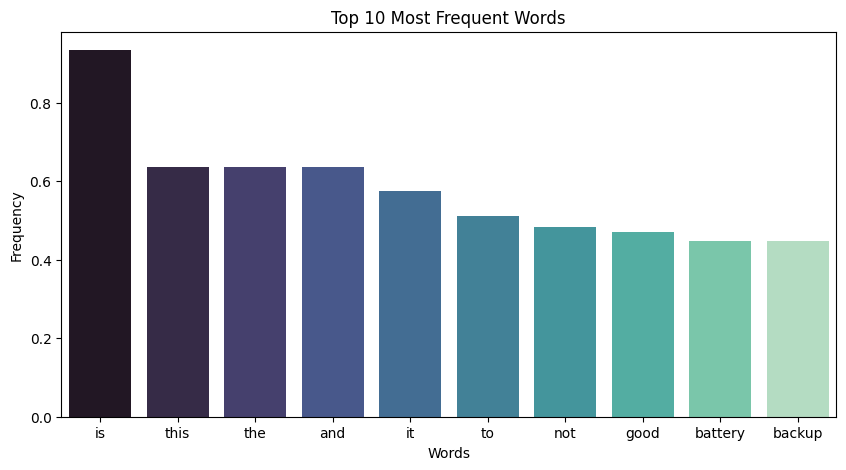

In [46]:
plt.figure(figsize=(10, 5))
sns.barplot(x=[word[0] for word in words_freq], y=[word[1] for word in words_freq], palette='mako')
plt.title('Top 10 Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()
